In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv('ec2_metrics_pydantic.csv')
dataset.head()
dataset.columns

Index(['instance_id', 'timestamp', 'cpu', 'memory', 'gpu_utilization',
       'gpu_memory_utilization', 'gpu_encoder_session_count', 'network_in',
       'network_out', 'network_packets_in', 'network_packets_out',
       'disk_read_ops', 'disk_write_ops', 'disk_read_bytes',
       'disk_write_bytes', 'volume_read_bytes', 'volume_write_bytes',
       'volume_read_ops', 'volume_write_ops'],
      dtype='object')

In [3]:
# 2) choose numeric features for isolation forest
features = ['cpu', 'memory', 'gpu_utilization',
       'gpu_memory_utilization', 'gpu_encoder_session_count', 'network_in',
       'network_out', 'network_packets_in', 'network_packets_out',
       'disk_read_ops', 'disk_write_ops', 'disk_read_bytes',
       'disk_write_bytes', 'volume_read_bytes', 'volume_write_bytes',
       'volume_read_ops', 'volume_write_ops']

X = dataset[features].copy()

# 3) optional: missing value handling (if needed)
X = X.fillna(X.median())

# 4) train IsolationForest
model = IsolationForest(
    n_estimators=100,
    max_samples="auto",
    contamination=0.005,  # adjust to ~expected anomaly ratio
    random_state=42,
    n_jobs=-1,
)
model.fit(X)

# 5) add anomaly score + label to DataFrame
dataset["anomaly_score"] = model.decision_function(X)   # higher is "normal"
dataset["anomaly"] = model.predict(X)                   # 1=normal, -1=anomaly
dataset["is_anomaly"] = dataset["anomaly"].map({1: 0, -1: 1})

# 6) quick validation / sample
print(dataset[["timestamp", "instance_id", "cpu", "anomaly_score", "is_anomaly"]].head(10))
print("anomaly count:", int(dataset["is_anomaly"].sum()))

                   timestamp instance_id    cpu  anomaly_score  is_anomaly
0  2026-03-01T00:00:00+00:00  i-0abcd123  81.67      -0.234045           1
1  2026-03-01T00:05:00+00:00  i-0abcd123  31.19       0.073143           0
2  2026-03-01T00:10:00+00:00  i-0abcd123  24.90       0.073062           0
3  2026-03-01T00:15:00+00:00  i-0abcd123  41.25       0.071702           0
4  2026-03-01T00:20:00+00:00  i-0abcd123  44.25       0.041673           0
5  2026-03-01T00:25:00+00:00  i-0abcd123  31.05       0.096549           0
6  2026-03-01T00:30:00+00:00  i-0abcd123  43.87       0.044438           0
7  2026-03-01T00:35:00+00:00  i-0abcd123  22.87       0.111917           0
8  2026-03-01T00:40:00+00:00  i-0abcd123  38.22       0.048690           0
9  2026-03-01T00:45:00+00:00  i-0abcd123  25.98       0.040007           0
anomaly count: 60


In [4]:
# sample record (same feature names/order as training data)
record = {
    "cpu": [22.0],
    "memory": [40.2],
    "gpu_utilization": [0.0],
    "gpu_memory_utilization": [0.0],
    "gpu_encoder_session_count": [0.0],
    "network_in": [150000],
    "network_out": [130000],
    "network_packets_in": [100],
    "network_packets_out": [100],
    "disk_read_ops": [220],
    "disk_write_ops": [180],
    "disk_read_bytes": [1024000],
    "disk_write_bytes": [860000],
    "volume_read_bytes": [512000],
    "volume_write_bytes": [430000],
    "volume_read_ops": [50],
    "volume_write_ops": [40],
}

X_new = pd.DataFrame(record)

# if you used fillna/scale in training, apply same ops here:
# X_new = scaler.transform(X_new)  # if scaler used
# X_new = X_new.fillna(X_new.median())  # if fillna used

pred = model.predict(X_new)           # 1 normal, -1 anomaly
score = model.decision_function(X_new)  # higher => more normal

print("pred", pred.tolist())
print("score", score.tolist())

pred [-1]
score [-0.07735509535083229]


In [5]:

anomalies = dataset[dataset["is_anomaly"] == 1].copy()

print("anomaly count:", len(anomalies))
if len(anomalies) > 0:
    display(anomalies.reset_index(drop=True))
else:
    print("No anomalies found at the current contamination threshold.")


anomaly count: 60


,instance_id,timestamp,cpu,memory,gpu_utilization,gpu_memory_utilization,gpu_encoder_session_count,network_in,network_out,network_packets_in,...,disk_write_ops,disk_read_bytes,disk_write_bytes,volume_read_bytes,volume_write_bytes,volume_read_ops,volume_write_ops,anomaly_score,anomaly,is_anomaly
0,i-0abcd123,2026-03-01T00:00:00+00:00,81.67,87.47,25.38,19.30,4,1118383,1591218,2251,...,1104,420836,378393,121065,267857,1698,1213,-0.234045,-1,1
1,i-0abcd123,2026-03-01T16:40:00+00:00,93.46,98.48,45.33,38.50,2,774708,1712469,1667,...,957,450386,181488,288015,235826,934,1764,-0.226606,-1,1
2,i-0abcd123,2026-03-02T09:20:00+00:00,95.31,88.58,34.66,49.78,3,1855488,1555458,2035,...,1443,333309,68318,158207,187214,1414,1108,-0.198425,-1,1
3,i-0abcd123,2026-03-03T02:00:00+00:00,97.60,91.69,44.08,37.01,2,971523,1397218,2775,...,1198,335101,202678,343348,344430,564,1472,-0.232482,-1,1
4,i-0abcd123,2026-03-03T18:40:00+00:00,94.08,98.11,32.37,39.33,2,576974,1666255,3784,...,691,434978,276547,263993,155441,1790,846,-0.223950,-1,1
5,i-0abcd123,2026-03-04T11:20:00+00:00,88.36,84.34,38.72,47.75,3,1389956,1590052,3763,...,1245,375042,198729,129195,227436,580,965,-0.229916,-1,1
6,i-0abcd123,2026-03-05T04:00:00+00:00,89.07,93.70,36.25,45.57,1,975514,1327814,3729,...,611,230606,452567,64045,310190,1389,1930,-0.220186,-1,1
7,i-0abcd123,2026-03-05T20:40:00+00:00,84.36,99.86,37.75,40.74,4,1551456,1019563,4927,...,666,347028,193678,344543,150099,784,1917,-0.227190,-1,1
8,i-0abcd123,2026-03-06T13:20:00+00:00,86.70,90.13,41.28,45.38,3,1938760,1758748,2139,...,1209,106221,368698,350726,65634,1667,1568,-0.218555,-1,1
9,i-0abcd123,2026-03-07T06:00:00+00:00,85.12,82.24,35.05,19.94,1,686947,1108823,2077,...,1355,495313,286800,235873,412065,1218,1786,-0.218138,-1,1


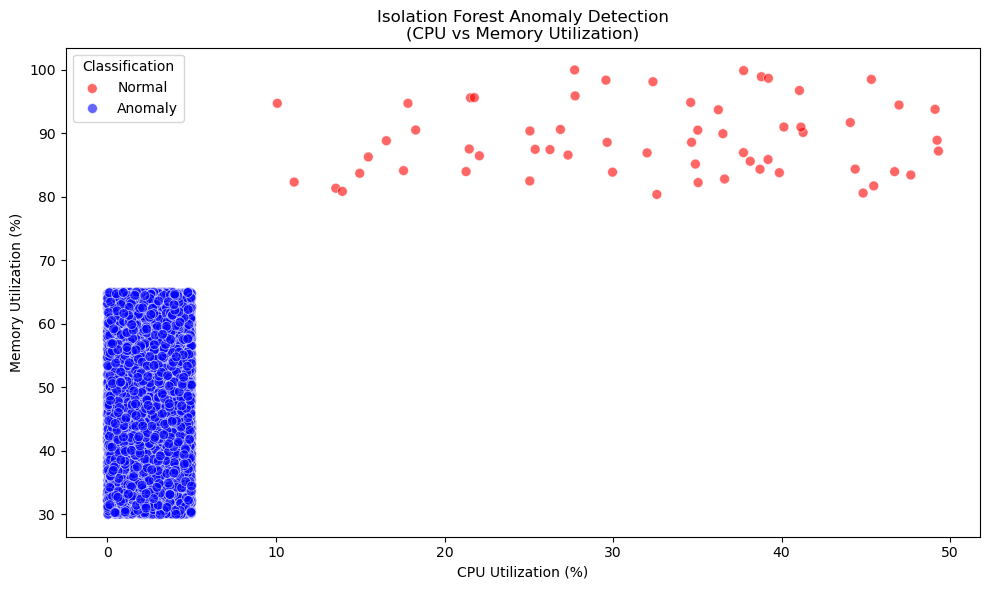

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dataset,
    x="gpu_utilization",
    y="memory",
    hue="is_anomaly",
    palette={0: "blue", 1: "red"},
    alpha=0.6,
    s=50
)
plt.title("Isolation Forest Anomaly Detection\n(CPU vs Memory Utilization)")
plt.xlabel("CPU Utilization (%)")
plt.ylabel("Memory Utilization (%)")
plt.legend(labels=["Normal", "Anomaly"], title="Classification")
plt.tight_layout()
plt.show()

In [7]:

import joblib

# save the trained model
model_path = "isolation_forest_model_with_gpu.pkl"
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")


Model saved to isolation_forest_model_with_gpu.pkl


# lstm model


In [1]:
import sys
import subprocess
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-8
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100.0)


def build_train_sequences(values: np.ndarray, lookback: int):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback : i])
        y.append(values[i])
    return np.array(X), np.array(y)


def build_test_sequences(all_values: np.ndarray, test_start_idx: int, lookback: int):
    X, y = [], []
    start_i = max(test_start_idx, lookback)
    for i in range(start_i, len(all_values)):
        X.append(all_values[i - lookback : i])
        y.append(all_values[i])
    return np.array(X), np.array(y)


# Load EC2 metrics data for time-series forecasting
ts_df = pd.read_csv("ec2_metrics_pydantic.csv")
ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"], errors="coerce")
ts_df = ts_df.dropna(subset=["timestamp"]).sort_values(["instance_id", "timestamp"]).reset_index(drop=True)

metric_cols = [
    "cpu",
    "memory",
    "gpu_utilization",
    "gpu_memory_utilization",
    "gpu_encoder_session_count",
    "network_in",
    "network_out",
    "network_packets_in",
    "network_packets_out",
    "disk_read_ops",
    "disk_write_ops",
    "disk_read_bytes",
    "disk_write_bytes",
    "volume_read_bytes",
    "volume_write_bytes",
    "volume_read_ops",
    "volume_write_ops",
]

lookback = 24
train_ratio = 0.8
min_rows_required = lookback + 30

instance_ids = ts_df["instance_id"].dropna().unique().tolist()
results = []
trained_instances = []
skipped_instances = []
selected_instance = None
selected_model = None
selected_scaler = None
selected_all_scaled = None

for instance_id in instance_ids:
    inst_df = ts_df[ts_df["instance_id"] == instance_id].copy()
    inst_df = inst_df.sort_values("timestamp")

    for col in metric_cols:
        inst_df[col] = pd.to_numeric(inst_df[col], errors="coerce")

    if len(inst_df) < min_rows_required:
        skipped_instances.append((instance_id, "not enough rows"))
        continue

    split_idx = int(len(inst_df) * train_ratio)
    if split_idx <= lookback or len(inst_df) - split_idx < 5:
        skipped_instances.append((instance_id, "insufficient train/test split"))
        continue

    train_raw = inst_df.iloc[:split_idx][metric_cols].copy()
    test_raw = inst_df.iloc[split_idx:][metric_cols].copy()

    # Causal imputation: forward-fill only, then fallback to train medians
    train_filled = train_raw.ffill()
    train_medians = train_filled.median()
    train_filled = train_filled.fillna(train_medians)

    combined_raw = pd.concat([train_raw, test_raw], axis=0)
    combined_filled = combined_raw.ffill().fillna(train_medians)

    train_filled = combined_filled.iloc[:split_idx].copy()
    test_filled = combined_filled.iloc[split_idx:].copy()

    # Leakage-safe scaling: fit only on train, apply to train/test
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_filled)
    test_scaled = scaler.transform(test_filled)

    all_scaled = np.vstack([train_scaled, test_scaled])

    X_train, y_train = build_train_sequences(train_scaled, lookback)
    X_test, y_test = build_test_sequences(all_scaled, split_idx, lookback)

    if len(X_train) < 20 or len(X_test) < 5:
        skipped_instances.append((instance_id, "insufficient sequence samples"))
        continue

    model = Sequential(
        [
            LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
            Dropout(0.2),
            LSTM(32),
            Dense(64, activation="relu"),
            Dense(len(metric_cols)),
        ]
    )
    model.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

    model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
    )

    pred_scaled = model.predict(X_test, verbose=0)
    pred = scaler.inverse_transform(pred_scaled)
    true = scaler.inverse_transform(y_test)

    # Naive baseline: predict next value as last observed value in lookback window
    naive_pred_scaled = X_test[:, -1, :]
    naive_pred = scaler.inverse_transform(naive_pred_scaled)

    for idx, col in enumerate(metric_cols):
        model_mae = mean_absolute_error(true[:, idx], pred[:, idx])
        baseline_mae = mean_absolute_error(true[:, idx], naive_pred[:, idx])

        model_smape = smape(true[:, idx], pred[:, idx])
        baseline_smape = smape(true[:, idx], naive_pred[:, idx])

        mean_abs_true = np.mean(np.abs(true[:, idx])) + 1e-8
        model_nmae_pct = (model_mae / mean_abs_true) * 100.0
        baseline_nmae_pct = (baseline_mae / mean_abs_true) * 100.0

        results.append(
            {
                "instance_id": instance_id,
                "metric": col,
                "model_mae": model_mae,
                "baseline_mae": baseline_mae,
                "model_smape_pct": model_smape,
                "baseline_smape_pct": baseline_smape,
                "model_nmae_pct": model_nmae_pct,
                "baseline_nmae_pct": baseline_nmae_pct,
            }
        )

    trained_instances.append(instance_id)

    if selected_instance is None:
        selected_instance = instance_id
        selected_model = model
        selected_scaler = scaler
        selected_all_scaled = all_scaled

if not trained_instances:
    raise ValueError("No instances had enough clean data to train and evaluate. Adjust lookback/min_rows_required.")

results_df = pd.DataFrame(results)

print(f"Trained instances: {len(trained_instances)}")
if skipped_instances:
    print(f"Skipped instances: {len(skipped_instances)}")

# Macro average across instances and metrics
macro_summary = (
    results_df[["model_mae", "baseline_mae", "model_smape_pct", "baseline_smape_pct", "model_nmae_pct", "baseline_nmae_pct"]]
    .mean()
    .to_frame(name="macro_avg")
)

print("\nMacro average (all instances x all metrics):")
display(macro_summary)

# Per-metric average comparison (model vs naive baseline)
per_metric_summary = (
    results_df.groupby("metric", as_index=False)[
        ["model_mae", "baseline_mae", "model_smape_pct", "baseline_smape_pct", "model_nmae_pct", "baseline_nmae_pct"]
    ]
    .mean()
    .sort_values("model_mae")
)

print("Per-metric average comparison (model vs naive baseline):")
display(per_metric_summary)

# Next-step forecast for one representative instance
last_window = selected_all_scaled[-lookback:].reshape(1, lookback, len(metric_cols))
next_pred_scaled = selected_model.predict(last_window, verbose=0)
next_pred = selected_scaler.inverse_transform(next_pred_scaled)[0]

print(f"\nRepresentative instance for next-step forecast: {selected_instance}")
print("Predicted next EC2 metrics:")
for col, value in zip(metric_cols, next_pred):
    print(f"  {col}: {value:.4f}")

C:\Users\Maryem Belghouthi\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Trained instances: 1

Macro average (all instances x all metrics):


,macro_avg
model_mae,8340.733191
baseline_mae,11749.435695
model_smape_pct,43.304099
baseline_smape_pct,53.087976
model_nmae_pct,40.027529
baseline_nmae_pct,53.430175


Per-metric average comparison (model vs naive baseline):


,metric,model_mae,baseline_mae,model_smape_pct,baseline_smape_pct,model_nmae_pct,baseline_nmae_pct
5,gpu_encoder_session_count,0.511423,0.522500,137.297069,100.224999,100.443063,102.618656
7,gpu_utilization,1.401290,1.916767,56.731229,76.775035,52.452339,71.747362
6,gpu_memory_utilization,1.411673,1.968579,56.502003,77.257012,52.420245,73.100084
0,cpu,7.786570,10.301425,26.348576,34.273097,25.811493,34.147917
8,memory,9.105841,12.230037,19.386880,25.932402,19.107069,25.662666
4,disk_write_ops,34.661888,48.940417,27.105709,36.345361,28.096450,39.670429
2,disk_read_ops,34.870422,50.282083,23.059856,31.730657,24.223912,34.930141
14,volume_read_ops,104.255735,140.757500,35.605200,47.139473,34.191877,46.163054
16,volume_write_ops,105.836128,145.861250,36.319626,48.783113,34.801637,47.962925
11,network_packets_in,123.958299,175.789583,45.273106,60.851281,43.372330,61.507812



Representative instance for next-step forecast: i-0abcd123
Predicted next EC2 metrics:
  cpu: 30.0398
  memory: 47.8790
  gpu_utilization: 2.9104
  gpu_memory_utilization: 2.7020
  gpu_encoder_session_count: 0.4773
  network_in: 140671.7812
  network_out: 126289.3359
  network_packets_in: 278.5624
  network_packets_out: 296.6007
  disk_read_ops: 142.2400
  disk_write_ops: 128.6340
  disk_read_bytes: 29357.5254
  disk_write_bytes: 27583.7500
  volume_read_bytes: 55297.9531
  volume_write_bytes: 56970.8516
  volume_read_ops: 311.9330
  volume_write_ops: 317.7148


In [2]:
# Save trained LSTM model
import os

save_dir = "../models/forecasting"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "lstm_model.keras")
model.save(model_path)

print(f"LSTM model saved to: {model_path}")

LSTM model saved to: ../models/forecasting\lstm_model.keras
